In [1]:
!pip install -q shap lime lightgbm openpyxl

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


# Import libraries

In [88]:
import os
import glob
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import shap

from lime.lime_tabular import LimeTabularExplainer

from sklearn.inspection import permutation_importance
from sklearn.inspection import PartialDependenceDisplay
from scipy.stats import spearmanr

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("SHAP:", shap.__version__)

SHAP: 0.52.0


In [3]:
OUTPUT_DIR = "XAI_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Load datasets

In [9]:
ds1 = pd.read_csv("/content/CKD_preprocessed.csv")
ds2 = pd.read_csv("/content/DiabeticCKD_engineered.csv")

target_ds1 = "d_status"

X_ds1 = ds1.drop(columns=[target_ds1])
y_ds1 = ds1[target_ds1].astype(int)

print("Dataset 1:", X_ds1.shape)
print(X_ds1.columns.tolist())

Dataset 1: (380, 20)
['age', 'gender', 'u_clarity', 'ph', 'sp_g', 'albumin', 'glucose', 'sugar', 'kb', 'bpigment', 'ur_bi', 'blood', 'pus_cells', 'red_cells', 'epi_cells', 'mt', 'co', 'gc', 'bacteria', 'cc']


In [10]:
target_ds2 = "CKD"

X_ds2 = ds2.drop(target_ds2, axis=1)
y_ds2 = ds2[target_ds2].astype(int)

print("Dataset 2:", X_ds2.shape)
print(X_ds2.columns.tolist())

Dataset 2: (4000, 33)
['Gender', 'Job', 'Family_Background_of_Diabetes', 'Height', 'Diabetic_Year', 'Age', 'Average_Age', 'Weight', 'Average_Weight', 'BMI', 'Follow_suggested_Diet', 'Take_Medicine_for_Diabetes', 'Take_Insulin', 'Hypertension', 'Heart_Disease', 'Sleep', 'Water_Consumption', 'Smoke', 'Zarda_Betel_Leaf', 'Walk_Regularly', 'Urination_Properly', 'Urinary_Infection', 'Pain_killer', 'Calorie_Intake', 'Current_BMI', 'BMI_Diabetes', 'Age_Diabetes', 'Weight_Diff', 'Age_Diff', 'BMI_per_Year', 'Lifestyle_Score', 'Risk_Score', 'Treatment_Score']


# Load folds

In [13]:
ds1_fold_paths = sorted(glob.glob("/content/Random_Forest/fold*.joblib", recursive=True))
ds2_fold_paths = sorted(glob.glob("/content/LightGBM/fold*.joblib", recursive=True))

print("Dataset 1 files:")
print(ds1_fold_paths)

print("\nDataset 2 files:")
print(ds2_fold_paths)

Dataset 1 files:
['/content/Random_Forest/fold1.joblib', '/content/Random_Forest/fold2.joblib', '/content/Random_Forest/fold3.joblib', '/content/Random_Forest/fold4.joblib', '/content/Random_Forest/fold5.joblib']

Dataset 2 files:
['/content/LightGBM/fold1.joblib', '/content/LightGBM/fold2.joblib', '/content/LightGBM/fold3.joblib', '/content/LightGBM/fold4.joblib', '/content/LightGBM/fold5.joblib']


In [14]:
ds1_folds = [
    joblib.load(path)
    for path in ds1_fold_paths
]

ds2_folds = [
    joblib.load(path)
    for path in ds2_fold_paths
]

print(len(ds1_folds))
print(len(ds2_folds))

print(ds1_folds[0].keys())
print(ds2_folds[0].keys())

5
5
dict_keys(['fold', 'best_pipeline', 'best_params', 'threshold', 'train_indices', 'test_indices', 'inner_best_score', 'y_true', 'y_prob', 'y_pred'])
dict_keys(['fold', 'best_pipeline', 'best_params', 'threshold', 'train_indices', 'test_indices', 'inner_best_score', 'y_true', 'y_prob', 'y_pred'])


# Get model and data

In [26]:
def get_model_and_data(pipeline, X):

    # Get the actual fitted model
    model = pipeline.steps[-1][1]

    # No preprocessing inside the pipeline
    X_model = X.copy()

    feature_names = np.array(X_model.columns)

    return model, X_model, feature_names

# SHAP calculate function

In [27]:
def calculate_shap_for_folds(folds, X, dataset_name):

    results = []

    for fold in folds:

        fold_num = fold["fold"]
        test_indices = np.asarray(fold["test_indices"])
        pipeline = fold["best_pipeline"]
        X_test = X.iloc[test_indices].copy()

        print(f"{dataset_name} - Fold {fold_num}")

        model, X_test_model, feature_names = (
            get_model_and_data(
                pipeline,
                X_test
            )
        )

        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_test_model)

        # Binary classification
        if isinstance(shap_values, list):
            shap_values = shap_values[1]

        shap_values = np.asarray(shap_values)

        if shap_values.ndim == 3:
            shap_values = shap_values[:, :, 1]

        results.append({
            "fold": fold_num,
            "test_indices": test_indices,
            "X_test": X_test,
            "X_test_model": X_test_model,
            "feature_names": feature_names,
            "shap_values": shap_values,
            "pipeline": pipeline,
            "model": model
        })

        print(
            "  X:",
            X_test_model.shape,
            "| SHAP:",
            shap_values.shape
        )

    return results

# Calculate SHAP for both datasets

In [28]:
shap_ds1 = calculate_shap_for_folds(
    ds1_folds,
    X_ds1,
    "Dataset 1 - Random Forest"
)

shap_ds2 = calculate_shap_for_folds(
    ds2_folds,
    X_ds2,
    "Dataset 2 - LightGBM"
)

Dataset 1 - Random Forest - Fold 1
  X: (76, 20) | SHAP: (76, 20)
Dataset 1 - Random Forest - Fold 2
  X: (76, 20) | SHAP: (76, 20)
Dataset 1 - Random Forest - Fold 3
  X: (76, 20) | SHAP: (76, 20)
Dataset 1 - Random Forest - Fold 4
  X: (76, 20) | SHAP: (76, 20)
Dataset 1 - Random Forest - Fold 5
  X: (76, 20) | SHAP: (76, 20)
Dataset 2 - LightGBM - Fold 1
  X: (830, 33) | SHAP: (830, 33)
Dataset 2 - LightGBM - Fold 2
  X: (800, 33) | SHAP: (800, 33)
Dataset 2 - LightGBM - Fold 3
  X: (790, 33) | SHAP: (790, 33)
Dataset 2 - LightGBM - Fold 4
  X: (780, 33) | SHAP: (780, 33)
Dataset 2 - LightGBM - Fold 5
  X: (800, 33) | SHAP: (800, 33)


# calculate SHAP stability

In [29]:
def calculate_shap_stability(shap_results):

    feature_names = shap_results[0]["feature_names"]

    # Mean absolute SHAP per feature, per fold
    fold_importances = []

    for result in shap_results:
        importance = np.mean(
            np.abs(result["shap_values"]),
            axis=0
        )
        fold_importances.append(importance)

    fold_importances = np.vstack(fold_importances)

    rows = []

    for i, feature in enumerate(feature_names):

        values = fold_importances[:, i]

        # Rank within each fold
        fold_ranks = []

        for row in fold_importances:
            ranks = (
                pd.Series(row)
                .rank(
                    ascending=False,
                    method="min"
                )
            )
            fold_ranks.append(ranks.iloc[i])

        rows.append({
            "Feature": feature,
            "Mean_Abs_SHAP": values.mean(),
            "SD_Abs_SHAP": values.std(ddof=1),
            "Median_Rank": np.median(fold_ranks),
            "Top10_Folds": np.sum(
                np.array(fold_ranks) <= 10
            )
        })

    result = pd.DataFrame(rows)
    result = result.sort_values(
        "Mean_Abs_SHAP",
        ascending=False
    ).reset_index(drop=True)

    result["Overall_Rank"] = (np.arange(len(result)) + 1)

    return result

In [30]:
stability_ds1 = calculate_shap_stability(shap_ds1)
stability_ds2 = calculate_shap_stability(shap_ds2)

In [31]:
print("DATASET 1 — RANDOM FOREST")
display(stability_ds1.head(15))

DATASET 1 — RANDOM FOREST


,Feature,Mean_Abs_SHAP,SD_Abs_SHAP,Median_Rank,Top10_Folds,Overall_Rank
0,pus_cells,0.135707,0.008205,1.0,5,1
1,albumin,0.114725,0.012739,2.0,5,2
2,bacteria,0.057228,0.003066,3.0,5,3
3,red_cells,0.055425,0.009228,4.0,5,4
4,co,0.051158,0.006034,4.0,5,5
5,age,0.028419,0.006028,6.0,5,6
6,mt,0.023481,0.006455,8.0,4,7
7,u_clarity,0.023393,0.007221,9.0,3,8
8,gc,0.022980,0.006425,8.0,4,9
9,ph,0.017798,0.006042,12.0,2,10


In [32]:
print("\nDATASET 2 — LIGHTGBM")
display(stability_ds2.head(15))


DATASET 2 — LIGHTGBM


,Feature,Mean_Abs_SHAP,SD_Abs_SHAP,Median_Rank,Top10_Folds,Overall_Rank
0,Age_Diff,3.011873,1.346517,1.0,5,1
1,Diabetic_Year,1.677192,1.001087,2.0,5,2
2,Calorie_Intake,0.788821,0.588338,3.0,4,3
3,BMI_per_Year,0.697556,0.462943,6.0,4,4
4,BMI_Diabetes,0.683840,0.485040,5.0,4,5
5,Height,0.661808,0.448197,7.0,5,6
6,BMI,0.620089,0.505566,11.0,2,7
7,Age,0.616805,0.462681,9.0,5,8
8,Average_Age,0.579072,0.388387,10.0,4,9
9,Age_Diabetes,0.513973,0.439538,13.0,2,10


# Save SHAP stability tables



In [33]:
stability_ds1.to_csv(
    f"{OUTPUT_DIR}/Table5_SHAP_stability_Dataset1.csv",
    index=False
)

stability_ds2.to_csv(
    f"{OUTPUT_DIR}/Table5_SHAP_stability_Dataset2.csv",
    index=False
)

# Combine outer fold SHAP results

In [34]:
def combine_shap_results(shap_results):

    X_all = np.vstack([
        r["X_test_model"]
        for r in shap_results
    ])

    shap_all = np.vstack([
        r["shap_values"]
        for r in shap_results
    ])

    feature_names = shap_results[0]["feature_names"]

    X_all = pd.DataFrame(
        X_all,
        columns=feature_names
    )

    return X_all, shap_all

In [35]:
X_shap_ds1, values_ds1 = combine_shap_results(shap_ds1)
X_shap_ds2, values_ds2 = combine_shap_results(shap_ds2)

print(X_shap_ds1.shape, values_ds1.shape)
print(X_shap_ds2.shape, values_ds2.shape)

(380, 20) (380, 20)
(4000, 33) (4000, 33)


# CKD SHAP plot

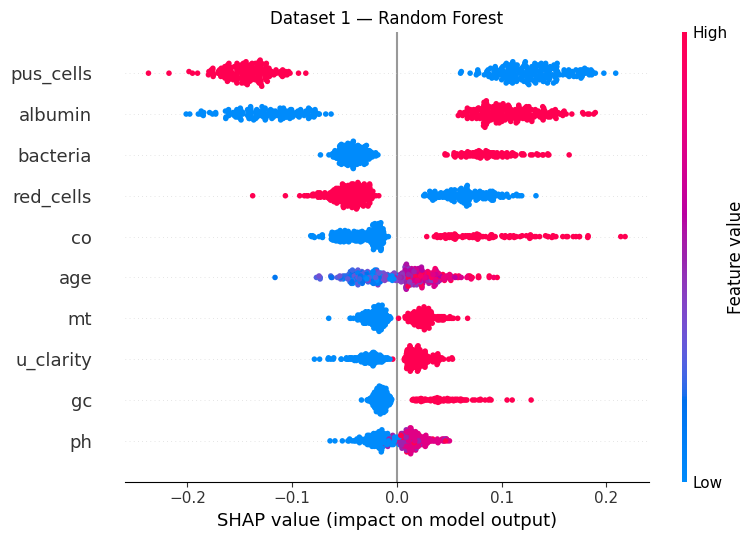

In [37]:
plt.figure(figsize=(9, 7))

shap.summary_plot(
    values_ds1,
    X_shap_ds1,
    max_display=10,
    show=False
)

plt.title("Dataset 1 — Random Forest")
plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/Figure_4a_SHAP_Dataset1.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# DiabeticCKD SHAP plot

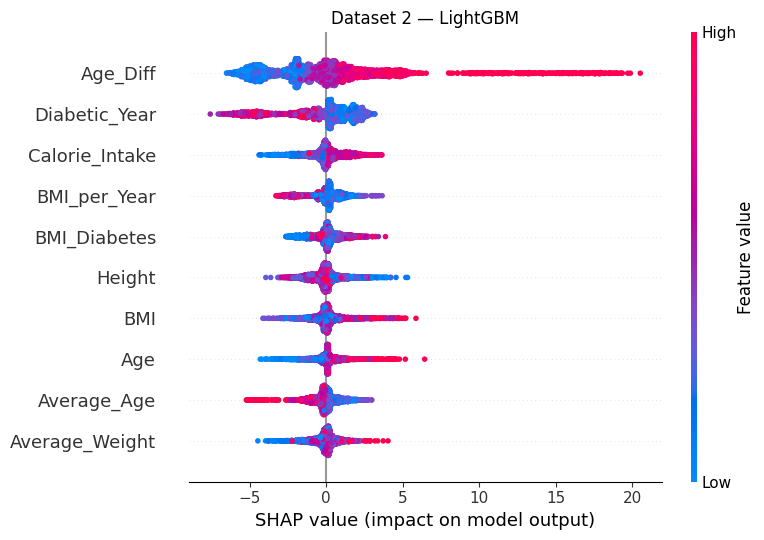

In [38]:
plt.figure(figsize=(9, 7))

shap.summary_plot(
    values_ds2,
    X_shap_ds2,
    max_display=10,
    show=False
)

plt.title("Dataset 2 — LightGBM")

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/Figure_4b_SHAP_Dataset2.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [39]:
print("DATASET 1 TOP FEATURES")
print(
    stability_ds1[
        [
            "Overall_Rank",
            "Feature",
            "Mean_Abs_SHAP",
            "SD_Abs_SHAP",
            "Median_Rank",
            "Top10_Folds"
        ]
    ].head(15).to_string(index=False)
)

print("\nDATASET 2 TOP FEATURES")
print(
    stability_ds2[
        [
            "Overall_Rank",
            "Feature",
            "Mean_Abs_SHAP",
            "SD_Abs_SHAP",
            "Median_Rank",
            "Top10_Folds"
        ]
    ].head(15).to_string(index=False)
)

DATASET 1 TOP FEATURES
 Overall_Rank   Feature  Mean_Abs_SHAP  SD_Abs_SHAP  Median_Rank  Top10_Folds
            1 pus_cells       0.135707     0.008205          1.0            5
            2   albumin       0.114725     0.012739          2.0            5
            3  bacteria       0.057228     0.003066          3.0            5
            4 red_cells       0.055425     0.009228          4.0            5
            5        co       0.051158     0.006034          4.0            5
            6       age       0.028419     0.006028          6.0            5
            7        mt       0.023481     0.006455          8.0            4
            8 u_clarity       0.023393     0.007221          9.0            3
            9        gc       0.022980     0.006425          8.0            4
           10        ph       0.017798     0.006042         12.0            2
           11  bpigment       0.017189     0.002058         10.0            3
           12        kb       0.016575   

# Permutation Importance

In [40]:
def calculate_permutation_importance(folds, X, y, scoring):

    fold_results = []

    for fold in folds:

        fold_num = fold["fold"]
        test_indices = np.asarray(fold["test_indices"])

        pipeline = fold["best_pipeline"]

        X_test = X.iloc[test_indices].copy()
        y_test = y.iloc[test_indices].copy()

        print(f"Permutation importance - Fold {fold_num}")

        result = permutation_importance(
            pipeline,
            X_test,
            y_test,
            scoring=scoring,
            n_repeats=10,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )

        fold_results.append(result.importances_mean)

    fold_results = np.vstack(fold_results)

    summary = pd.DataFrame({
        "Feature": X.columns,
        "Mean_Permutation_Importance": fold_results.mean(axis=0),
        "SD_Permutation_Importance": fold_results.std(axis=0, ddof=1)
    })

    summary = summary.sort_values(
        "Mean_Permutation_Importance",
        ascending=False
    ).reset_index(drop=True)

    summary["Permutation_Rank"] = (np.arange(len(summary)) + 1)

    return summary

In [41]:
perm_ds1 = calculate_permutation_importance(ds1_folds, X_ds1, y_ds1, scoring="roc_auc")
perm_ds2 = calculate_permutation_importance(ds2_folds, X_ds2, y_ds2, scoring="average_precision")

Permutation importance - Fold 1
Permutation importance - Fold 2
Permutation importance - Fold 3
Permutation importance - Fold 4
Permutation importance - Fold 5
Permutation importance - Fold 1
Permutation importance - Fold 2
Permutation importance - Fold 3
Permutation importance - Fold 4
Permutation importance - Fold 5


In [42]:
print("DATASET 1")
display(perm_ds1.head(15))

DATASET 1


,Feature,Mean_Permutation_Importance,SD_Permutation_Importance,Permutation_Rank
0,pus_cells,0.049446,0.030671,1
1,albumin,0.037159,0.010826,2
2,red_cells,0.018903,0.011581,3
3,co,0.015758,0.011138,4
4,bacteria,0.012259,0.006536,5
5,mt,0.003466,0.004187,6
6,kb,0.003196,0.002753,7
7,age,0.002074,0.001028,8
8,bpigment,0.001748,0.001175,9
9,blood,0.001678,0.001788,10


In [43]:
print("\nDATASET 2")
display(perm_ds2.head(15))


DATASET 2


,Feature,Mean_Permutation_Importance,SD_Permutation_Importance,Permutation_Rank
0,Age_Diff,0.380980,0.046804,1
1,Diabetic_Year,0.055320,0.027135,2
2,Height,0.046475,0.017985,3
3,Weight_Diff,0.038389,0.013476,4
4,Take_Insulin,0.016784,0.004598,5
5,Age_Diabetes,0.016319,0.008876,6
6,Calorie_Intake,0.015385,0.015395,7
7,BMI_Diabetes,0.014444,0.014181,8
8,Walk_Regularly,0.010421,0.010572,9
9,Age,0.010090,0.006072,10


# Save Permutation Importance results

In [44]:
perm_ds1.to_csv(
    f"{OUTPUT_DIR}/Permutation_Dataset1.csv",
    index=False
)

perm_ds2.to_csv(
    f"{OUTPUT_DIR}/Permutation_Dataset2.csv",
    index=False
)

# Compare SHAP and permutation importance

In [45]:
def compare_shap_permutation(shap_stability, permutation):

    shap_df = shap_stability[["Feature", "Overall_Rank"]].copy()

    shap_df = shap_df.rename(
        columns={
            "Overall_Rank": "SHAP_Rank"
        }
    )

    perm_df = permutation[["Feature", "Permutation_Rank"]].copy()

    merged = shap_df.merge(
        perm_df,
        on="Feature",
        how="inner"
    )

    # Spearman correlation between rankings
    rho, p = spearmanr(
        merged["SHAP_Rank"],
        merged["Permutation_Rank"]
    )

    shap_top5 = set(
        merged.nsmallest(
            5,
            "SHAP_Rank"
        )["Feature"]
    )

    perm_top5 = set(
        merged.nsmallest(
            5,
            "Permutation_Rank"
        )["Feature"]
    )

    shap_top10 = set(
        merged.nsmallest(
            10,
            "SHAP_Rank"
        )["Feature"]
    )

    perm_top10 = set(
        merged.nsmallest(
            10,
            "Permutation_Rank"
        )["Feature"]
    )

    return {
        "Spearman_rho": rho,
        "Spearman_p": p,
        "Top5_overlap": len(shap_top5 & perm_top5),
        "Top10_overlap": len(shap_top10 & perm_top10),
        "SHAP_only_top10": sorted(
            shap_top10 - perm_top10
        ),
        "Permutation_only_top10": sorted(
            perm_top10 - shap_top10
        ),
        "merged": merged
    }

In [46]:
comparison_ds1 = compare_shap_permutation(stability_ds1, perm_ds1)
comparison_ds2 = compare_shap_permutation(stability_ds2, perm_ds2)

print("DATASET 1")
print("Spearman rho:", comparison_ds1["Spearman_rho"])
print("Top-5 overlap:", comparison_ds1["Top5_overlap"])
print("Top-10 overlap:", comparison_ds1["Top10_overlap"])

print("\nDATASET 2")
print("Spearman rho:", comparison_ds2["Spearman_rho"])
print("Top-5 overlap:", comparison_ds2["Top5_overlap"])
print("Top-10 overlap:", comparison_ds2["Top10_overlap"])

DATASET 1
Spearman rho: 0.7639097744360903
Top-5 overlap: 5
Top-10 overlap: 7

DATASET 2
Spearman rho: 0.6938502673796793
Top-5 overlap: 2
Top-10 overlap: 7


# Save the comparison

In [47]:
comparison_table = pd.DataFrame([
    {
        "Dataset": "Dataset 1",
        "Model": "Random Forest",
        "Spearman_Rho": comparison_ds1["Spearman_rho"],
        "Top5_Overlap": comparison_ds1["Top5_overlap"],
        "Top10_Overlap": comparison_ds1["Top10_overlap"]
    },
    {
        "Dataset": "Dataset 2",
        "Model": "LightGBM",
        "Spearman_Rho": comparison_ds2["Spearman_rho"],
        "Top5_Overlap": comparison_ds2["Top5_overlap"],
        "Top10_Overlap": comparison_ds2["Top10_overlap"]
    }
])

display(comparison_table)

comparison_table.to_csv(
    f"{OUTPUT_DIR}/SHAP_permutation_comparison.csv",
    index=False
)

,Dataset,Model,Spearman_Rho,Top5_Overlap,Top10_Overlap
0,Dataset 1,Random Forest,0.76391,5,7
1,Dataset 2,LightGBM,0.69385,2,7


# Select the PDP/ICE variables

In [48]:
def select_top_continuous_features(stability_df, X, n=2):

    numeric_features = X.select_dtypes(include=np.number).columns.tolist()

    selected = [
        feature
        for feature in stability_df["Feature"]
        if feature in numeric_features
    ]

    return selected[:n]

In [49]:
pdp_features_ds1 = select_top_continuous_features(stability_ds1, X_ds1, n=2)
pdp_features_ds2 = select_top_continuous_features(stability_ds2, X_ds2, n=2)

print("Dataset 1 PDP/ICE features:")
print(pdp_features_ds1)

print("\nDataset 2 PDP/ICE features:")
print(pdp_features_ds2)

Dataset 1 PDP/ICE features:
['pus_cells', 'albumin']

Dataset 2 PDP/ICE features:
['Age_Diff', 'Diabetic_Year']


# Generate PDP + ICE

In [54]:
def make_pdp_ice(model, X, feature, output_path, title, grid_resolution=20, sample_size=300):

    X = X.copy()

    # Use a manageable sample for ICE
    if len(X) > sample_size:
        X_plot = X.sample(
            sample_size,
            random_state=RANDOM_STATE
        ).copy()
    else:
        X_plot = X.copy()

    # Feature grid
    values = np.linspace(
        X[feature].quantile(0.05),
        X[feature].quantile(0.95),
        grid_resolution
    )

    ice_curves = []

    for value in values:

        X_temp = X_plot.copy()
        X_temp[feature] = value

        # Probability of positive class
        probs = model.predict_proba(X_temp)[:, 1]

        ice_curves.append(probs)

    ice_curves = np.asarray(ice_curves).T

    # PDP = average ICE
    pdp = ice_curves.mean(axis=0)

    # Plot
    fig, ax = plt.subplots(figsize=(8, 6))

    # ICE curves
    for curve in ice_curves:
        ax.plot(values, curve, alpha=0.08)

    # PDP
    ax.plot(values, pdp, linewidth=3, label="PDP")

    ax.set_xlabel(feature)
    ax.set_ylabel("Predicted probability of CKD")
    ax.set_title(title)
    ax.legend()

    plt.tight_layout()

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    return pd.DataFrame({
        feature: values,
        "PDP": pdp
    })

# For Dataset-1 Random Forest

In [55]:
rf_model = ds1_folds[0]["best_pipeline"]
if hasattr(rf_model, "steps"):
    rf_model = rf_model.steps[-1][1]

Dataset 1: pus_cells


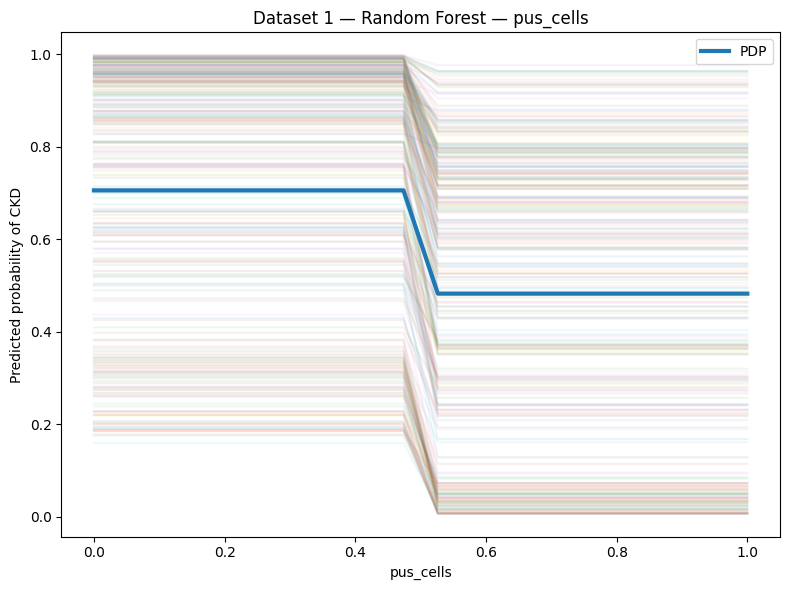

Dataset 1: albumin


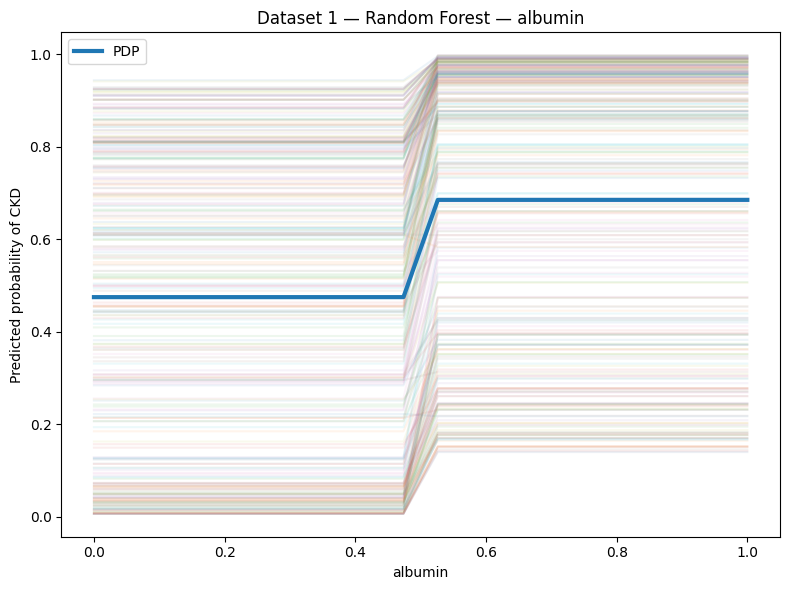

In [56]:
pdp_ds1 = {}

for feature in pdp_features_ds1:

    print("Dataset 1:", feature)

    pdp_ds1[feature] = make_pdp_ice(
        model=rf_model,
        X=X_ds1,
        feature=feature,
        output_path=(
            f"{OUTPUT_DIR}/"
            f"PDP_ICE_Dataset1_{feature}.png"
        ),
        title=(
            f"Dataset 1 — Random Forest — "
            f"{feature}"
        )
    )

# For Dataset2 - LightGBM

In [57]:
lgbm_model = ds2_folds[0]["best_pipeline"]

if hasattr(lgbm_model, "steps"):
    lgbm_model = lgbm_model.steps[-1][1]

Dataset 2: Age_Diff


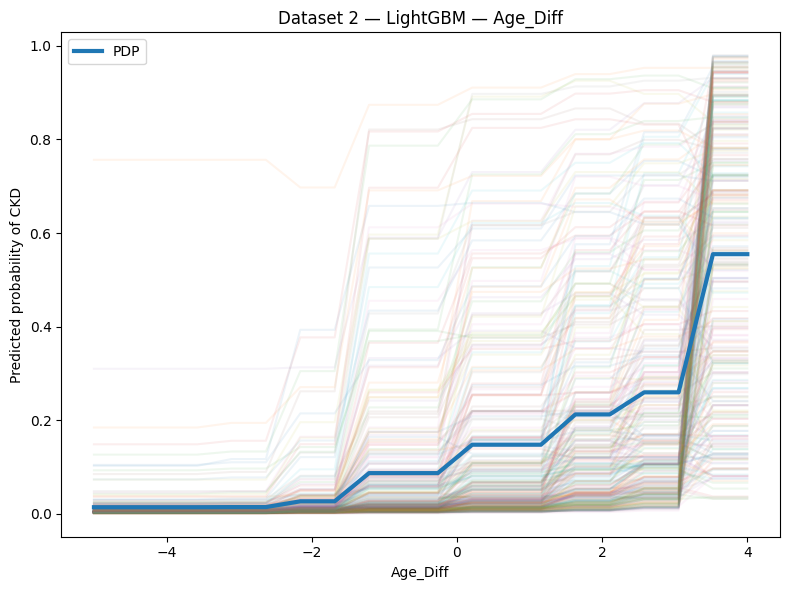

Dataset 2: Diabetic_Year


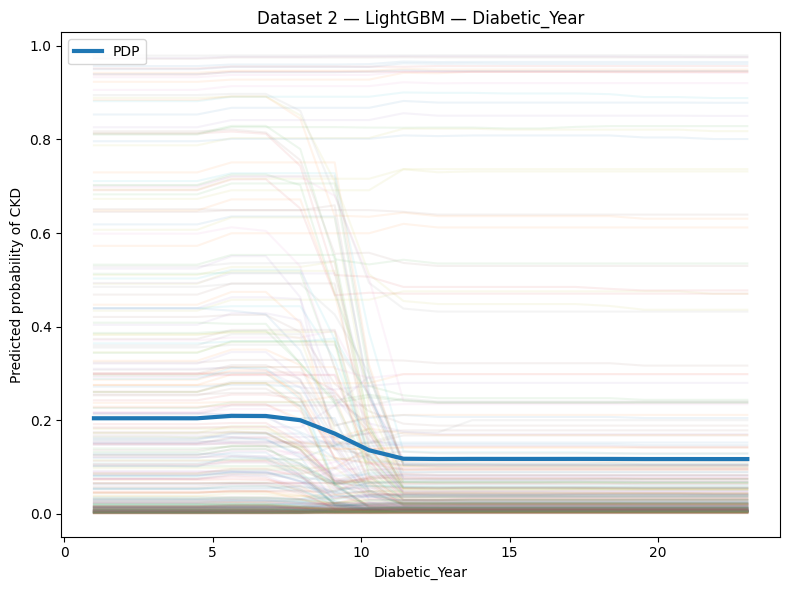

In [58]:
pdp_ds2 = {}

for feature in pdp_features_ds2:

    print("Dataset 2:", feature)

    pdp_ds2[feature] = make_pdp_ice(
        model=lgbm_model,
        X=X_ds2,
        feature=feature,
        output_path=(
            f"{OUTPUT_DIR}/"
            f"PDP_ICE_Dataset2_{feature}.png"
        ),
        title=(
            f"Dataset 2 — LightGBM — "
            f"{feature}"
        )
    )

# Save PDP/ICE plots

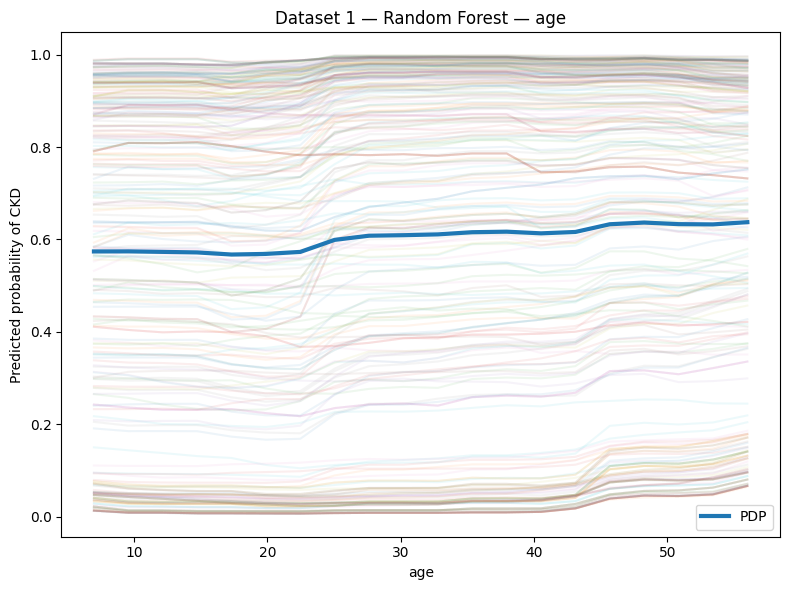

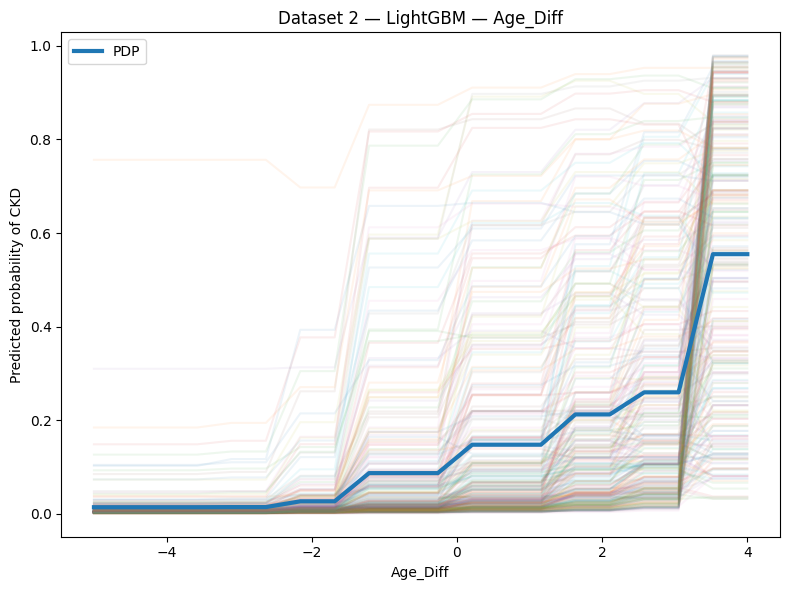

In [107]:
pdp_ds1 = make_pdp_ice(
    model=rf_model,
    X=X_ds1,
    feature="age",
    output_path=f"{OUTPUT_DIR}/Figure_PDP_ICE_Dataset1_age.png",
    title="Dataset 1 — Random Forest — age"
)

pdp_ds2 = make_pdp_ice(
    model=lgbm_model,
    X=X_ds2,
    feature="Age_Diff",
    output_path=f"{OUTPUT_DIR}/Figure_PDP_ICE_Dataset2_Age_Diff.png",
    title="Dataset 2 — LightGBM — Age_Diff"
)

# PDP/ICE + Interaction panel

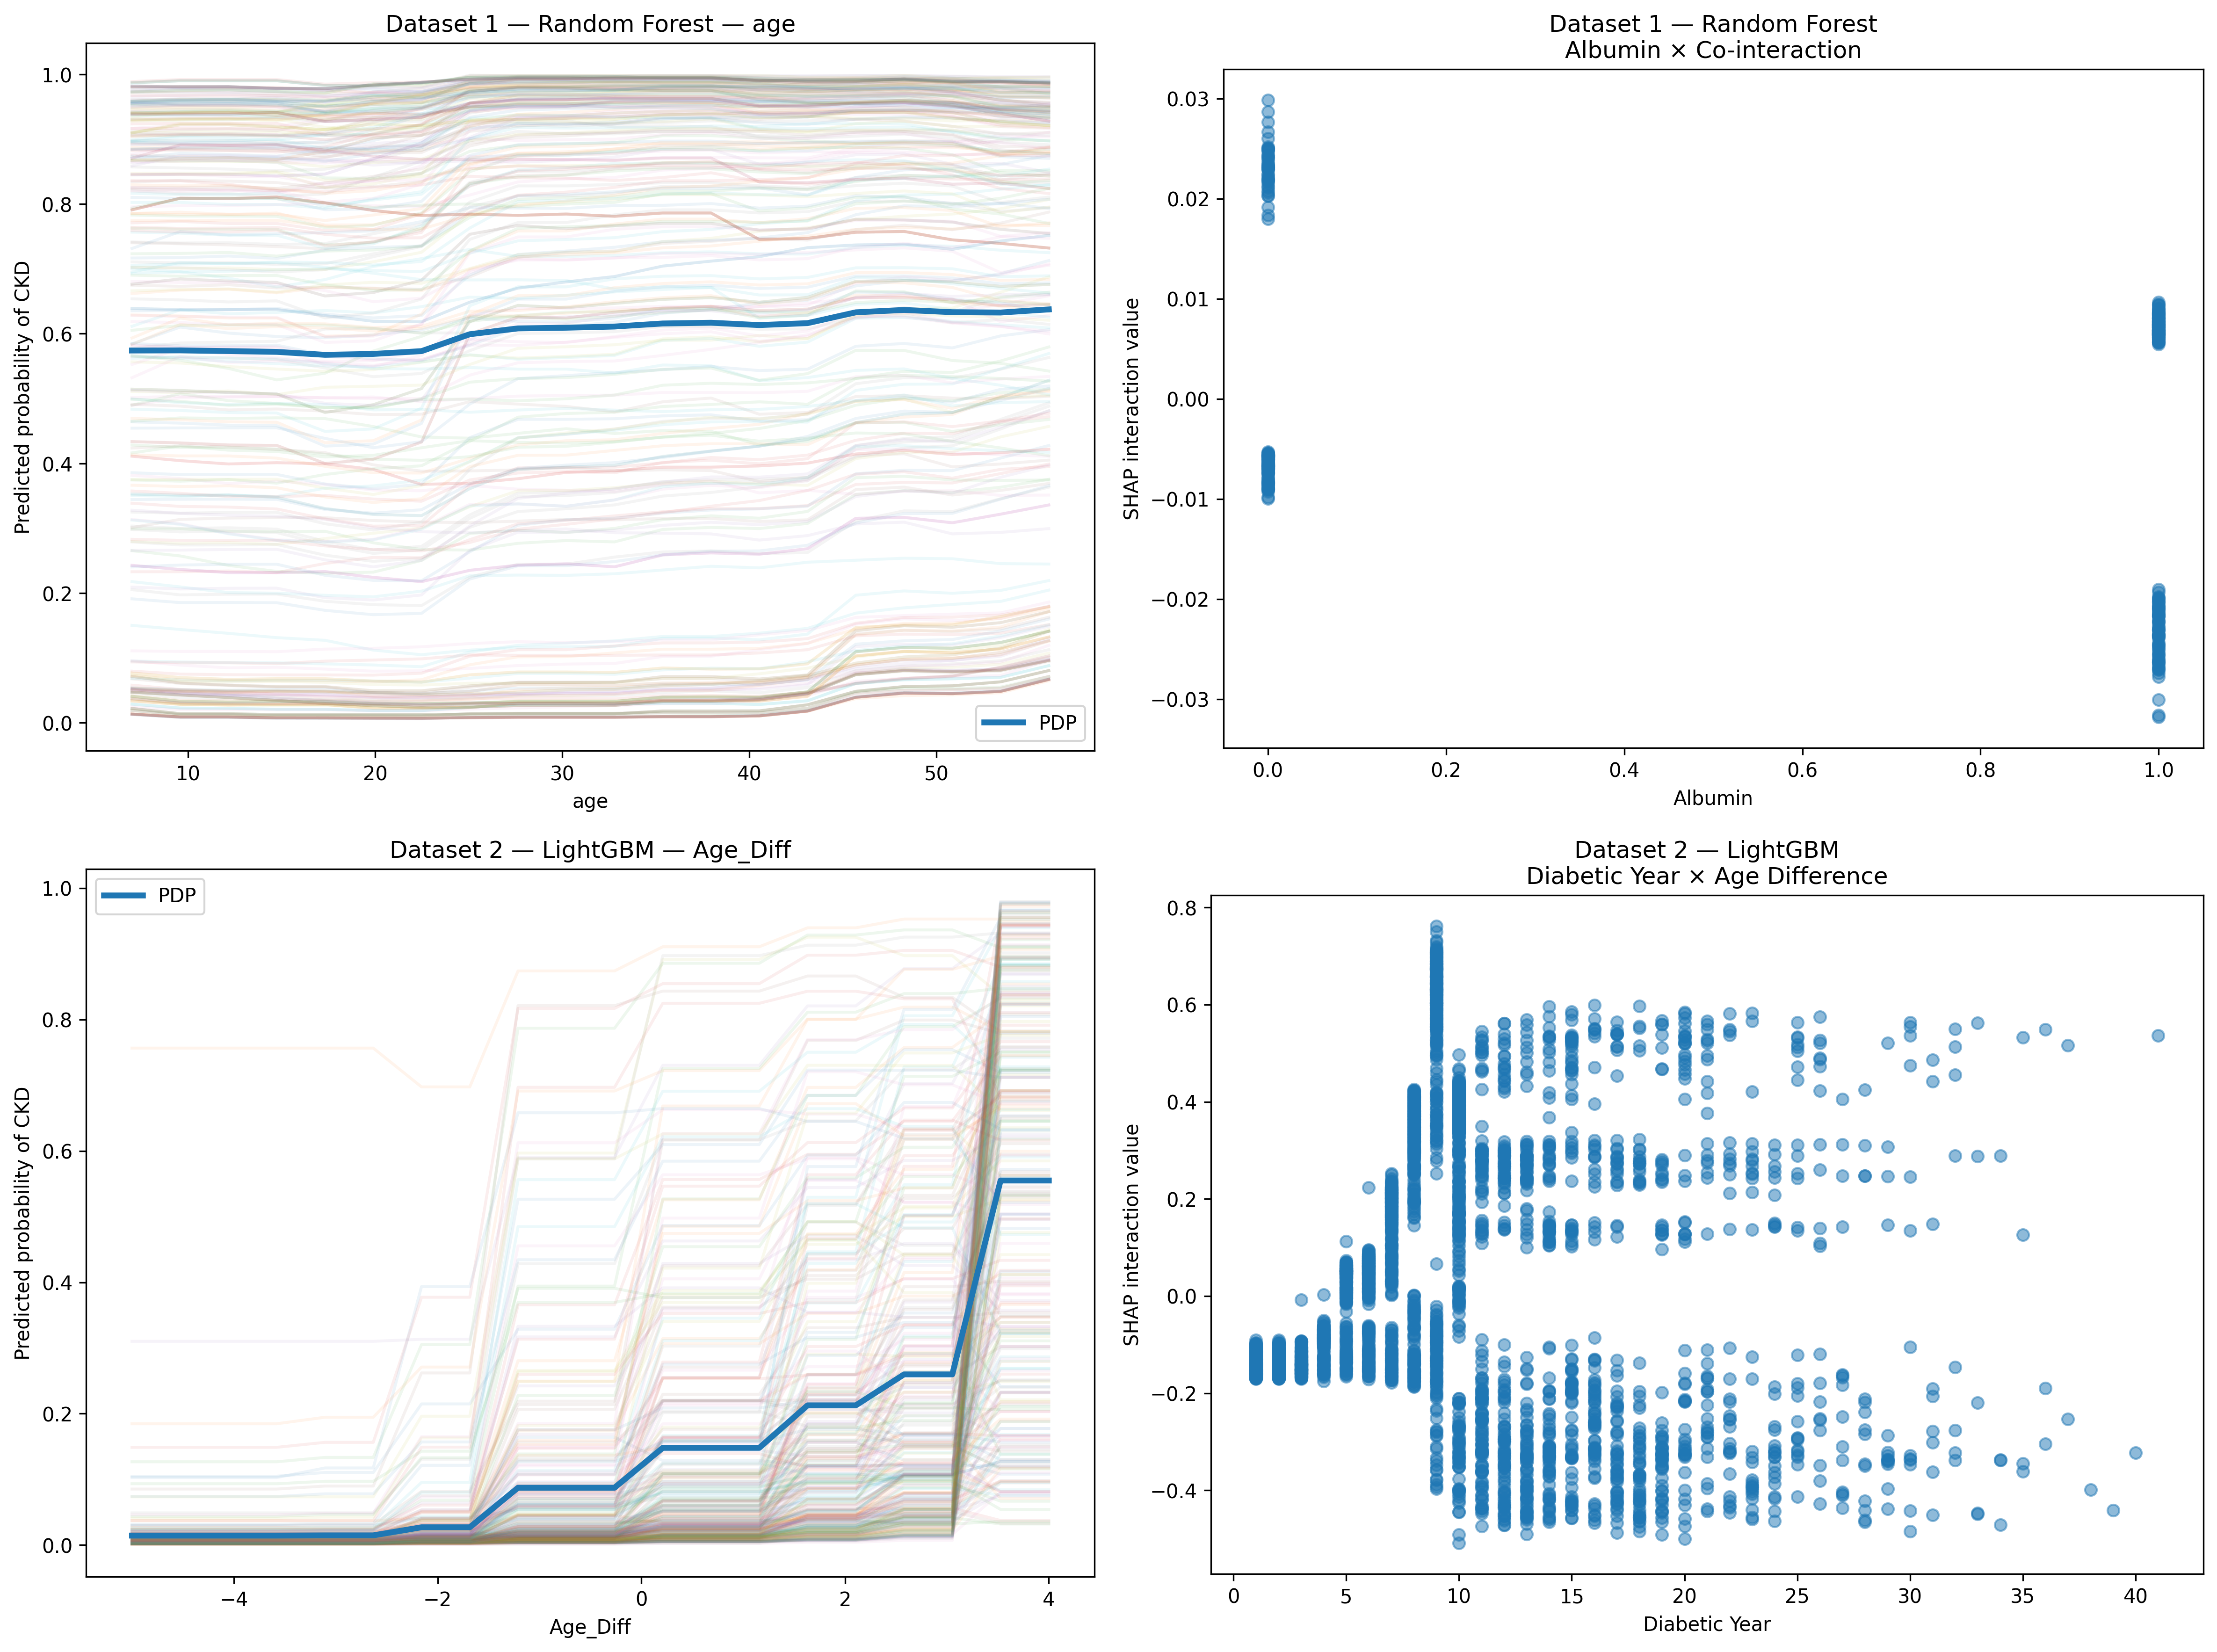

In [110]:
figure5_files = [
    f"{OUTPUT_DIR}/Figure_PDP_ICE_Dataset1_age.png",
    f"{OUTPUT_DIR}/Figure_5b_Interaction_Dataset1.png",
    f"{OUTPUT_DIR}/PDP_ICE_Dataset2_Age_Diff.png",
    f"{OUTPUT_DIR}/Figure_5b_Interaction_Dataset2.png"
]

images = [Image.open(f).convert("RGB") for f in figure5_files]

w = max(im.width for im in images)
h = max(im.height for im in images)

canvas = Image.new(
    "RGB",
    (2*w, 2*h),
    "white"
)

positions = [
    (0, 0),
    (w, 0),
    (0, h),
    (w, h)
]

for im, pos in zip(images, positions):
    canvas.paste(im, pos)

canvas.save(
    f"{OUTPUT_DIR}/Figure_5_PDP_ICE_Interactions.png"
)

display(canvas)

# SHAP interaction analysis

In [61]:
def calculate_shap_interactions(shap_results):

    fold_interactions = []
    feature_names = shap_results[0]["feature_names"]

    for result in shap_results:

        model = result["model"]
        X_test = result["X_test_model"]

        print(f"Calculating interactions - Fold {result['fold']}")

        explainer = shap.TreeExplainer(model)

        interaction_values = explainer.shap_interaction_values(X_test)

        if isinstance(interaction_values, list):
            interaction_values = interaction_values[1]

        interaction_values = np.asarray(interaction_values)

        # Binary classification can sometimes return
        # (n_samples, n_features, n_features, 2)
        if interaction_values.ndim == 4:
            interaction_values = interaction_values[:, :, :, 1]

        # Mean absolute interaction strength
        mean_interaction = np.mean(np.abs(interaction_values), axis=0)
        fold_interactions.append(mean_interaction)

    return feature_names, fold_interactions

In [62]:
interaction_features_ds1, interaction_folds_ds1 = (
    calculate_shap_interactions(shap_ds1)
)

interaction_features_ds2, interaction_folds_ds2 = (
    calculate_shap_interactions(shap_ds2)
)

Calculating interactions - Fold 1
Calculating interactions - Fold 2
Calculating interactions - Fold 3
Calculating interactions - Fold 4
Calculating interactions - Fold 5
Calculating interactions - Fold 1
Calculating interactions - Fold 2
Calculating interactions - Fold 3
Calculating interactions - Fold 4
Calculating interactions - Fold 5


# Rank interaction pairs

In [63]:
def summarize_interactions(feature_names, interaction_folds):
    n_features = len(feature_names)
    rows = []

    for i in range(n_features):
        for j in range(i + 1, n_features):
            values = np.array([
                fold[i, j]
                for fold in interaction_folds
            ])

            rows.append({
                "Feature_1": feature_names[i],
                "Feature_2": feature_names[j],
                "Mean_Interaction": values.mean(),
                "SD_Interaction": values.std(ddof=1)
            })

    df = pd.DataFrame(rows)
    df = df.sort_values("Mean_Interaction",ascending=False).reset_index(drop=True)
    df["Interaction_Rank"] = (np.arange(len(df)) + 1)

    return df

In [64]:
interaction_ds1 = summarize_interactions(
    interaction_features_ds1,
    interaction_folds_ds1
)

interaction_ds2 = summarize_interactions(
    interaction_features_ds2,
    interaction_folds_ds2
)

In [65]:
print("DATASET 1")
display(interaction_ds1.head(10))

print("DATASET 2")
display(interaction_ds2.head(10))

DATASET 1


,Feature_1,Feature_2,Mean_Interaction,SD_Interaction,Interaction_Rank
0,albumin,co,0.014100,0.002112,1
1,albumin,pus_cells,0.009881,0.001265,2
2,age,pus_cells,0.006338,0.001906,3
3,albumin,bacteria,0.006153,0.000702,4
4,age,albumin,0.005694,0.001041,5
5,albumin,red_cells,0.005598,0.001012,6
6,pus_cells,co,0.005438,0.001017,7
7,red_cells,bacteria,0.005416,0.001553,8
8,pus_cells,bacteria,0.005315,0.001189,9
9,pus_cells,red_cells,0.005248,0.001045,10


DATASET 2


,Feature_1,Feature_2,Mean_Interaction,SD_Interaction,Interaction_Rank
0,Diabetic_Year,Age_Diff,0.375262,0.133168,1
1,Weight_Diff,Age_Diff,0.154022,0.080268,2
2,Age_Diabetes,Age_Diff,0.151126,0.102920,3
3,Age_Diff,BMI_per_Year,0.143351,0.098348,4
4,Gender,Height,0.136720,0.132955,5
5,Height,BMI,0.133307,0.095566,6
6,BMI_Diabetes,Age_Diff,0.130934,0.076898,7
7,Age,Average_Age,0.121593,0.089007,8
8,BMI,Age_Diff,0.116644,0.084459,9
9,BMI,Calorie_Intake,0.109816,0.104007,10


# Check interaction stability

In [66]:
def interaction_stability(feature_names, interaction_folds, top_n=10):
    pairs = []

    for i in range(len(feature_names)):
        for j in range(i + 1, len(feature_names)):
            pairs.append((i, j))

    fold_rankings = []

    for fold_matrix in interaction_folds:
        values = np.array([
            fold_matrix[i, j]
            for i, j in pairs
        ])

        order = np.argsort(-values)

        ranks = np.empty(len(order), dtype=int)
        ranks[order] = np.arange(1, len(order) + 1)

        fold_rankings.append(ranks)

    fold_rankings = np.asarray(fold_rankings)

    rows = []

    for k, (i, j) in enumerate(pairs):

        ranks = fold_rankings[:, k]
        rows.append({
            "Feature_1": feature_names[i],
            "Feature_2": feature_names[j],
            "Median_Rank": np.median(ranks),
            "Mean_Rank": ranks.mean(),
            "Top10_Folds": np.sum(ranks <= 10)
        })

    df = pd.DataFrame(rows)
    df = df.sort_values(
        ["Top10_Folds", "Median_Rank"],
        ascending=[False, True]
    ).reset_index(drop=True)

    return df

In [67]:
interaction_stability_ds1 = interaction_stability(
    interaction_features_ds1,
    interaction_folds_ds1
)

interaction_stability_ds2 = interaction_stability(
    interaction_features_ds2,
    interaction_folds_ds2
)

In [69]:
display(interaction_stability_ds1.head(10))

,Feature_1,Feature_2,Median_Rank,Mean_Rank,Top10_Folds
0,albumin,co,1.0,1.0,5
1,albumin,pus_cells,2.0,2.0,5
2,age,albumin,6.0,6.6,5
3,albumin,bacteria,6.0,5.4,5
4,albumin,red_cells,9.0,7.6,5
5,age,pus_cells,5.0,6.4,4
6,pus_cells,co,8.0,8.4,4
7,pus_cells,red_cells,9.0,9.0,4
8,red_cells,bacteria,8.0,9.0,3
9,pus_cells,bacteria,11.0,9.2,2


In [70]:
display(interaction_stability_ds2.head(10))

,Feature_1,Feature_2,Median_Rank,Mean_Rank,Top10_Folds
0,Diabetic_Year,Age_Diff,1.0,1.0,5
1,Age_Diabetes,Age_Diff,4.0,5.0,5
2,Weight_Diff,Age_Diff,4.0,5.6,5
3,Age_Diff,BMI_per_Year,7.0,8.2,4
4,Height,BMI,6.0,9.4,3
5,BMI_Diabetes,Age_Diff,6.0,11.2,3
6,BMI,Age_Diff,8.0,14.4,3
7,Age,Average_Age,10.0,12.6,3
8,Gender,Height,11.0,32.2,2
9,Height,Age_Diff,14.0,12.4,2


In [71]:
interaction_ds1.to_csv(
    f"{OUTPUT_DIR}/SHAP_interactions_Dataset1.csv",
    index=False
)

interaction_ds2.to_csv(
    f"{OUTPUT_DIR}/SHAP_interactions_Dataset2.csv",
    index=False
)

interaction_stability_ds1.to_csv(
    f"{OUTPUT_DIR}/SHAP_interaction_stability_Dataset1.csv",
    index=False
)

interaction_stability_ds2.to_csv(
    f"{OUTPUT_DIR}/SHAP_interaction_stability_Dataset2.csv",
    index=False
)

# combine all outer-fold predictions

In [72]:
def combine_fold_predictions(folds):

    records = []

    for fold in folds:

        test_indices = np.asarray(fold["test_indices"])
        y_true = np.asarray(fold["y_true"])
        y_prob = np.asarray(fold["y_prob"])
        y_pred = np.asarray(fold["y_pred"])

        threshold = fold["threshold"]

        for i in range(len(test_indices)):

            records.append({
                "fold": fold["fold"],
                "index": test_indices[i],
                "y_true": y_true[i],
                "y_prob": y_prob[i],
                "y_pred": y_pred[i],
                "threshold": threshold
            })

    return pd.DataFrame(records)

In [73]:
pred_ds1 = combine_fold_predictions(ds1_folds)
pred_ds2 = combine_fold_predictions(ds2_folds)

# Select TP and FN

In [74]:
def select_local_cases(predictions):

    tp = predictions[
        (predictions["y_true"] == 1) &
        (predictions["y_pred"] == 1)
    ].copy()

    fn = predictions[
        (predictions["y_true"] == 1) &
        (predictions["y_pred"] == 0)
    ].copy()

    if len(tp) == 0:
        raise ValueError("No true positive cases found.")

    if len(fn) == 0:
        raise ValueError("No false negative cases found.")

    # Representative TP:
    # probability closest to 0.75
    tp["distance"] = np.abs(tp["y_prob"] - 0.75)
    selected_tp = tp.sort_values("distance").iloc[0]

    # Representative FN:
    # highest probability among missed positives
    selected_fn = fn.sort_values(
        "y_prob",
        ascending=False
    ).iloc[0]

    return selected_tp, selected_fn

In [75]:
tp_ds1, fn_ds1 = select_local_cases(pred_ds1)
tp_ds2, fn_ds2 = select_local_cases(pred_ds2)

# Generate local SHAP explanations

In [76]:
def get_fold_for_case(folds, fold_number):
    for fold in folds:
        if fold["fold"] == fold_number:
            return fold

    raise ValueError(
        f"Fold {fold_number} not found."
    )

In [77]:
def local_shap_for_case(case, folds, X):
    fold = get_fold_for_case(
        folds,
        case["fold"]
    )
    model = fold["model"] if "model" in fold else fold["best_pipeline"]

    if hasattr(model, "steps"):
        model = model.steps[-1][1]

    idx = int(case["index"])

    X_case = X.iloc[[idx]].copy()

    explainer = shap.TreeExplainer(model)
    shap_value = explainer.shap_values(X_case)

    if isinstance(shap_value, list):
        shap_value = shap_value[1]

    shap_value = np.asarray(shap_value)

    if shap_value.ndim == 3:
        shap_value = shap_value[:, :, 1]

    return model, X_case, shap_value[0]

# SHAP waterfall plots for Dataset1 TP and FN

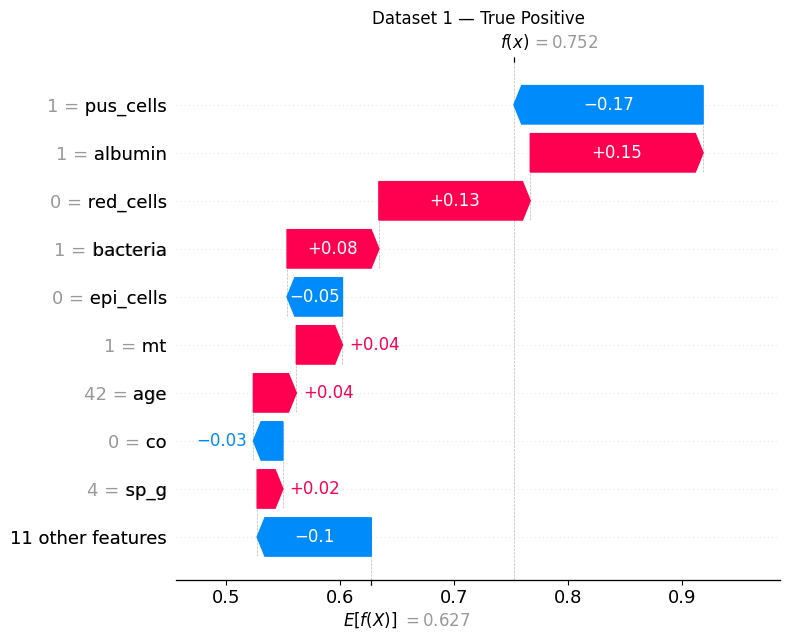

In [81]:
####### Dataset 1 TP ########
model, X_case, sv = local_shap_for_case(tp_ds1, ds1_folds, X_ds1)

shap_explanation = shap.Explanation(
    values=sv,
    base_values=model.predict_proba(X_case)[0, 1] - sv.sum(),
    data=X_case.iloc[0].values,
    feature_names=X_case.columns.tolist()
)

shap.plots.waterfall(
    shap_explanation,
    max_display=10,
    show=False
)

plt.title("Dataset 1 — True Positive")
plt.tight_layout()
plt.savefig(
    f"{OUTPUT_DIR}/Figure6_Dataset1_TP_SHAP.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

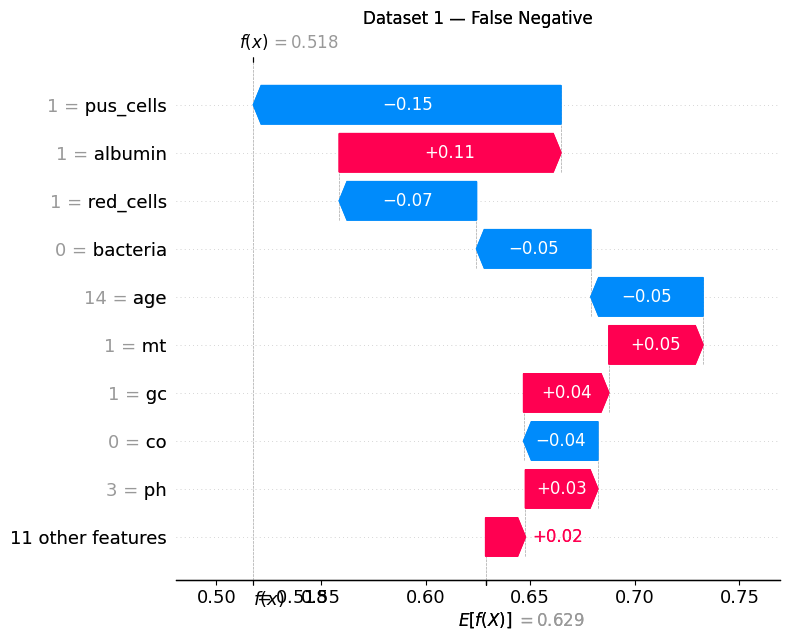

In [83]:
####### Dataset 1 FN ########
model, X_case, sv = local_shap_for_case(fn_ds1, ds1_folds, X_ds1)

shap_explanation = shap.Explanation(
    values=sv,
    base_values=model.predict_proba(X_case)[0, 1] - sv.sum(),
    data=X_case.iloc[0].values,
    feature_names=X_case.columns.tolist()
)

shap.plots.waterfall(
    shap_explanation,
    max_display=10,
    show=False
)

plt.title("Dataset 1 — False Negative")
plt.tight_layout()
plt.savefig(
    f"{OUTPUT_DIR}/Figure6_Dataset1_FN_SHAP.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

SHAP waterfall plots for Dataset2 TP and FN

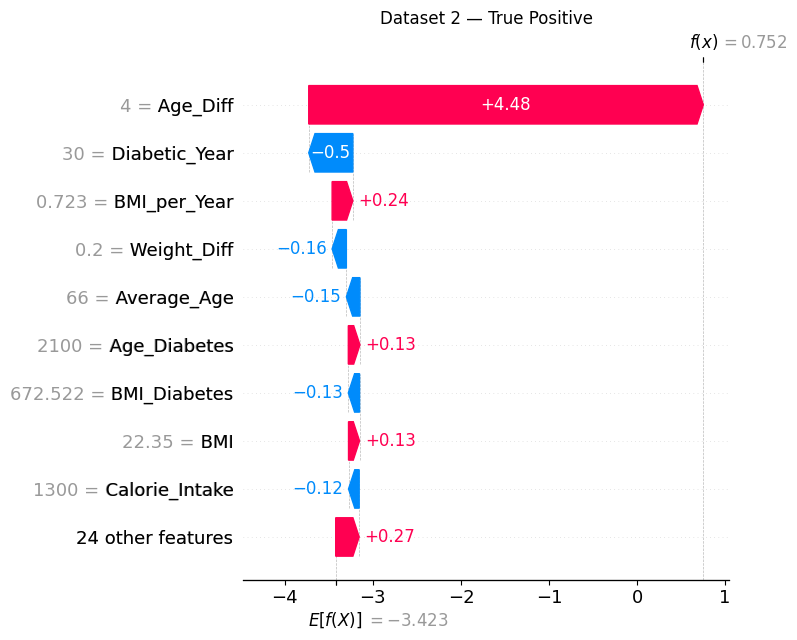

In [84]:
####### Dataset 2 TP ########
model, X_case, sv = local_shap_for_case(tp_ds2, ds2_folds, X_ds2)

shap_explanation = shap.Explanation(
    values=sv,
    base_values=model.predict_proba(X_case)[0, 1] - sv.sum(),
    data=X_case.iloc[0].values,
    feature_names=X_case.columns.tolist()
)

shap.plots.waterfall(
    shap_explanation,
    max_display=10,
    show=False
)

plt.title("Dataset 2 — True Positive")
plt.tight_layout()
plt.savefig(
    f"{OUTPUT_DIR}/Figure6_Dataset2_TP_SHAP.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

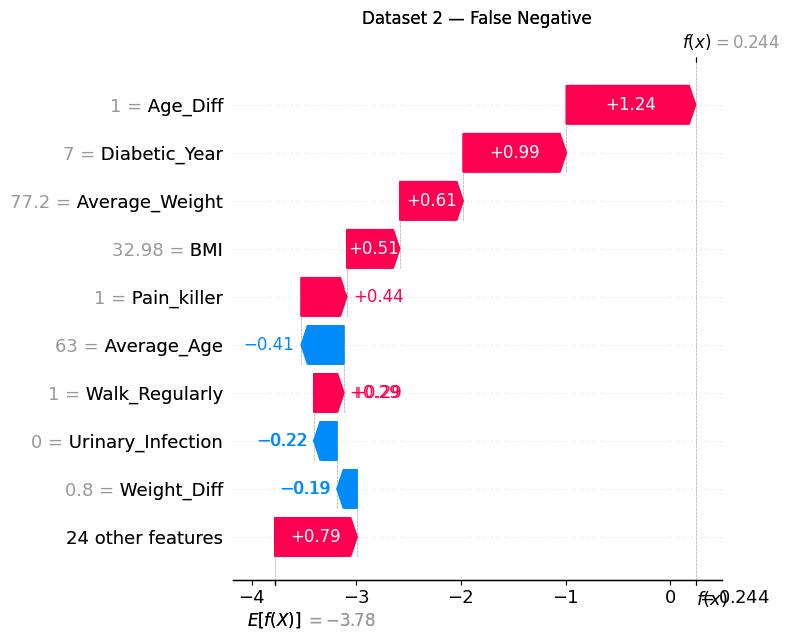

In [86]:
####### Dataset 2 FN ########
model, X_case, sv = local_shap_for_case(fn_ds2, ds2_folds, X_ds2)

shap_explanation = shap.Explanation(
    values=sv,
    base_values=model.predict_proba(X_case)[0, 1] - sv.sum(),
    data=X_case.iloc[0].values,
    feature_names=X_case.columns.tolist()
)

shap.plots.waterfall(
    shap_explanation,
    max_display=10,
    show=False
)

plt.title("Dataset 2 — False Negative")
plt.tight_layout()
plt.savefig(
    f"{OUTPUT_DIR}/Figure6_Dataset2_FN_SHAP.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Final four panel SHAP figure

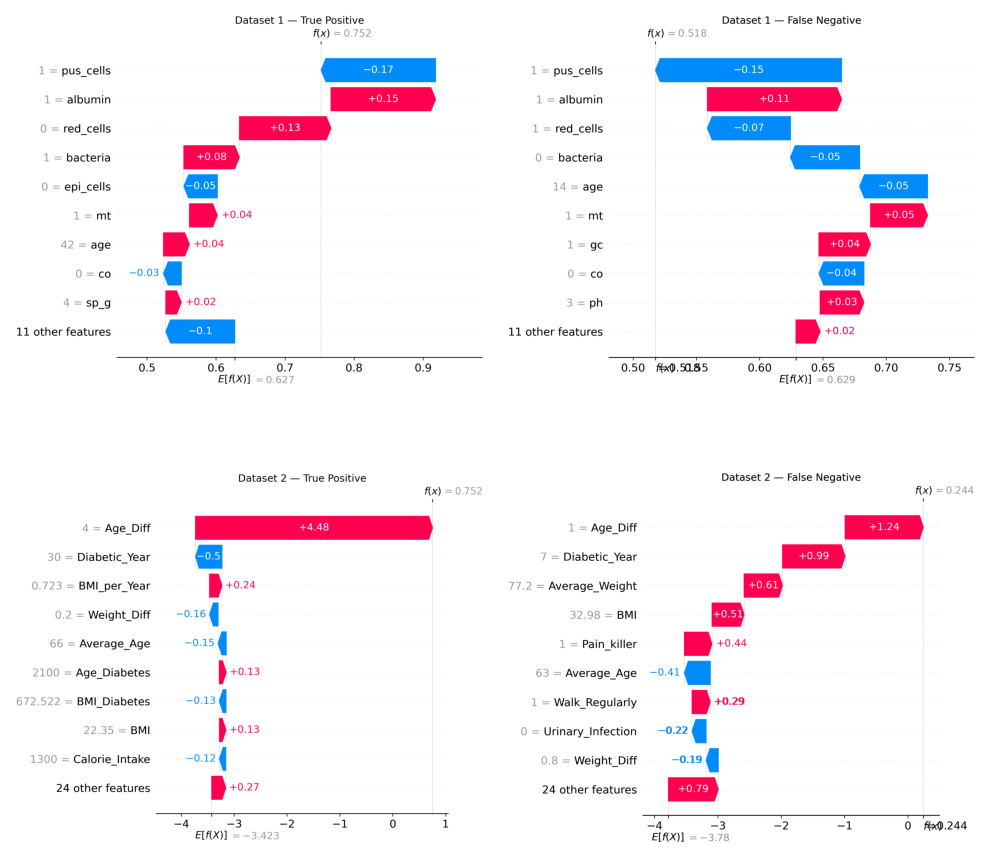

In [87]:
image_files = [
    f"{OUTPUT_DIR}/Figure6_Dataset1_TP_SHAP.png",
    f"{OUTPUT_DIR}/Figure6_Dataset1_FN_SHAP.png",
    f"{OUTPUT_DIR}/Figure6_Dataset2_TP_SHAP.png",
    f"{OUTPUT_DIR}/Figure6_Dataset2_FN_SHAP.png"
    ]

# Create a 2x2 panel grid
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 10))

for ax, img_path in zip(axes.flatten(), image_files):
    img = Image.open(img_path)
    ax.imshow(img)
    ax.axis('off')  # Hide axis ticks and borders

plt.tight_layout()
plt.savefig(
    f"{OUTPUT_DIR}/combined_SHAP_panel.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# LIME explanations

In [89]:
def make_lime_explanation(case, folds, X, y, dataset_name, case_name):
    fold = get_fold_for_case(folds, case["fold"])

    model = fold["best_pipeline"]

    if hasattr(model, "steps"):
        model = model.steps[-1][1]

    idx = int(case["index"])

    X_train_like = X.iloc[fold["train_indices"]].copy()
    X_case = X.iloc[idx].values

    explainer = LimeTabularExplainer(
        training_data=X_train_like.values,
        feature_names=X.columns.tolist(),
        class_names=["No CKD", "CKD"],
        mode="classification",
        discretize_continuous=True,
        random_state=RANDOM_STATE
    )

    explanation = explainer.explain_instance(
        X_case,
        model.predict_proba,
        num_features=8
    )

    # Save explanation as CSV
    lime_df = pd.DataFrame(
        explanation.as_list(),
        columns=["Feature", "LIME_Weight"]
    )

    lime_df["Dataset"] = dataset_name
    lime_df["Case"] = case_name

    lime_df.to_csv(
        f"{OUTPUT_DIR}/LIME_{dataset_name}_{case_name}.csv",
        index=False
    )

    return explanation, lime_df

In [90]:
lime_ds1_tp, lime_df_ds1_tp = make_lime_explanation(
    tp_ds1,
    ds1_folds,
    X_ds1,
    y_ds1,
    "Dataset1",
    "TP"
)

lime_ds1_fn, lime_df_ds1_fn = make_lime_explanation(
    fn_ds1,
    ds1_folds,
    X_ds1,
    y_ds1,
    "Dataset1",
    "FN"
)

lime_ds2_tp, lime_df_ds2_tp = make_lime_explanation(
    tp_ds2,
    ds2_folds,
    X_ds2,
    y_ds2,
    "Dataset2",
    "TP"
)

lime_ds2_fn, lime_df_ds2_fn = make_lime_explanation(
    fn_ds2,
    ds2_folds,
    X_ds2,
    y_ds2,
    "Dataset2",
    "FN"
)

# LIME comparison

In [91]:
lime_comparison = pd.concat(
    [
        lime_df_ds1_tp,
        lime_df_ds1_fn,
        lime_df_ds2_tp,
        lime_df_ds2_fn
    ],
    ignore_index=True
)

lime_comparison.to_csv(
    f"{OUTPUT_DIR}/Table_LIME_local_explanations.csv",
    index=False
)
display(lime_comparison)

,Feature,LIME_Weight,Dataset,Case
0,0.00 < pus_cells <= 1.00,-0.241096,Dataset1,TP
1,0.00 < albumin <= 1.00,0.228133,Dataset1,TP
2,red_cells <= 0.00,0.156207,Dataset1,TP
3,0.00 < bacteria <= 1.00,0.125791,Dataset1,TP
4,co <= 0.00,-0.113265,Dataset1,TP
5,0.00 < mt <= 1.00,0.088723,Dataset1,TP
6,gc <= 0.00,-0.073224,Dataset1,TP
7,kb <= 0.00,-0.069520,Dataset1,TP
8,0.00 < pus_cells <= 1.00,-0.251962,Dataset1,FN
9,0.00 < albumin <= 1.00,0.219036,Dataset1,FN


# Interaction plots

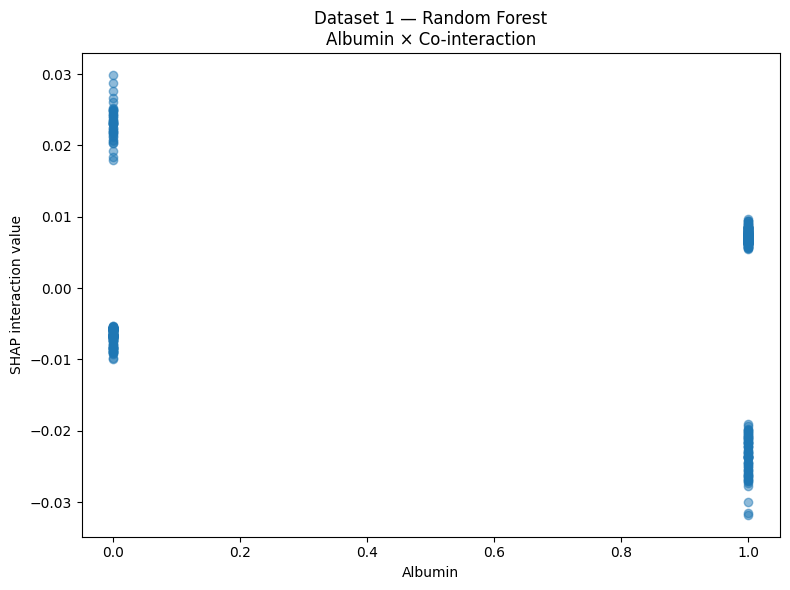

In [94]:
# model from fold 1
rf_model = ds1_folds[0]["best_pipeline"].steps[-1][1]
X_plot = X_ds1.copy()

# SHAP interaction values
explainer_rf = shap.TreeExplainer(rf_model)
interaction_values_rf = explainer_rf.shap_interaction_values(X_plot)

if isinstance(interaction_values_rf, list):
    interaction_values_rf = interaction_values_rf[1]

interaction_values_rf = np.asarray(interaction_values_rf)

if interaction_values_rf.ndim == 4:
    interaction_values_rf = interaction_values_rf[:, :, :, 1]

feature_names_rf = X_plot.columns.tolist()

i = feature_names_rf.index("albumin")
j = feature_names_rf.index("co")

# Interaction contribution for each observation
interaction_strength = interaction_values_rf[:, i, j]

plt.figure(figsize=(8, 6))
plt.scatter(
    X_plot["albumin"],
    interaction_strength,
    alpha=0.5
)
plt.xlabel("Albumin")
plt.ylabel("SHAP interaction value")
plt.title(
    "Dataset 1 — Random Forest\n"
    "Albumin × Co-interaction"
)
plt.tight_layout()
plt.savefig(
    f"{OUTPUT_DIR}/Figure_5b_Interaction_Dataset1.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

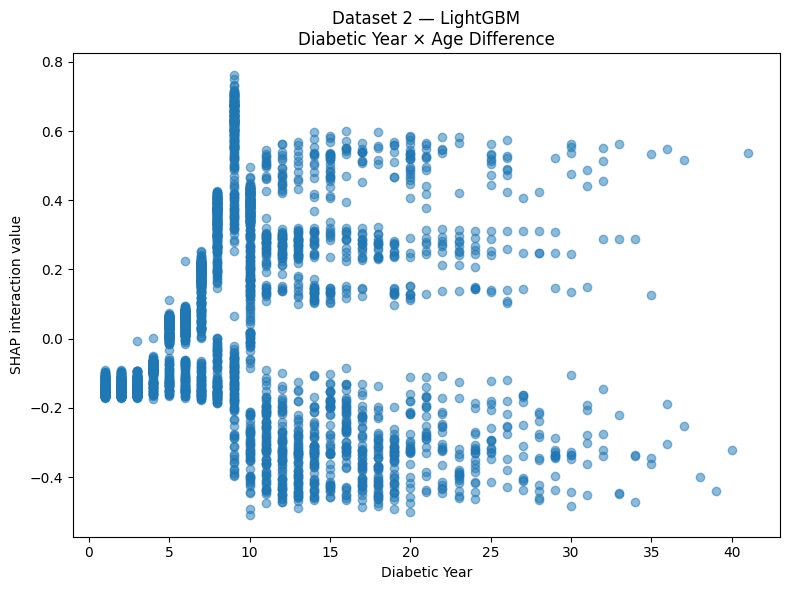

In [95]:
lgbm_model = ds2_folds[0]["best_pipeline"].steps[-1][1]
X_plot = X_ds2.copy()
explainer_lgbm = shap.TreeExplainer(lgbm_model)

interaction_values_lgbm = (explainer_lgbm.shap_interaction_values(X_plot))

if isinstance(interaction_values_lgbm, list):
    interaction_values_lgbm = interaction_values_lgbm[1]

interaction_values_lgbm = np.asarray(interaction_values_lgbm)

if interaction_values_lgbm.ndim == 4:
    interaction_values_lgbm = (
        interaction_values_lgbm[:, :, :, 1]
    )

feature_names_lgbm = X_plot.columns.tolist()

i = feature_names_lgbm.index("Diabetic_Year")
j = feature_names_lgbm.index("Age_Diff")

interaction_strength = (interaction_values_lgbm[:, i, j])

plt.figure(figsize=(8, 6))
plt.scatter(
    X_plot["Diabetic_Year"],
    interaction_strength,
    alpha=0.5
)
plt.xlabel("Diabetic Year")
plt.ylabel("SHAP interaction value")
plt.title(
    "Dataset 2 — LightGBM\n"
    "Diabetic Year × Age Difference"
)
plt.tight_layout()
plt.savefig(
    f"{OUTPUT_DIR}/Figure_5b_Interaction_Dataset2.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Main XAI summary table

In [97]:
xai_summary = pd.DataFrame([
    {
        "Dataset": "CKD",
        "Model": "Random Forest",
        "Top_SHAP_Feature": stability_ds1.iloc[0]["Feature"],
        "Top_SHAP_MeanAbs": stability_ds1.iloc[0]["Mean_Abs_SHAP"],
        "Top_SHAP_Top10_Folds": stability_ds1.iloc[0]["Top10_Folds"],
        "Top_Interaction": "albumin × co",
        "Interaction_Median_Rank": 1,
        "Interaction_Top10_Folds": 5,
        "SHAP_Permutation_Spearman":
            comparison_ds1["Spearman_rho"],
        "Top5_Overlap":
            comparison_ds1["Top5_overlap"],
        "Top10_Overlap":
            comparison_ds1["Top10_overlap"]
    },
    {
        "Dataset": "DiabeticCKD",
        "Model": "LightGBM",
        "Top_SHAP_Feature": stability_ds2.iloc[0]["Feature"],
        "Top_SHAP_MeanAbs": stability_ds2.iloc[0]["Mean_Abs_SHAP"],
        "Top_SHAP_Top10_Folds": stability_ds2.iloc[0]["Top10_Folds"],
        "Top_Interaction":
            "Diabetic_Year × Age_Diff",
        "Interaction_Median_Rank": 1,
        "Interaction_Top10_Folds": 5,
        "SHAP_Permutation_Spearman":
            comparison_ds2["Spearman_rho"],
        "Top5_Overlap":
            comparison_ds2["Top5_overlap"],
        "Top10_Overlap":
            comparison_ds2["Top10_overlap"]
    }
])

display(xai_summary)

xai_summary.to_csv(
    f"{OUTPUT_DIR}/Table_XAI_summary.csv",
    index=False
)

,Dataset,Model,Top_SHAP_Feature,Top_SHAP_MeanAbs,Top_SHAP_Top10_Folds,Top_Interaction,Interaction_Median_Rank,Interaction_Top10_Folds,SHAP_Permutation_Spearman,Top5_Overlap,Top10_Overlap
0,CKD,Random Forest,pus_cells,0.135707,5,albumin × co,1,5,0.76391,5,7
1,DiabeticCKD,LightGBM,Age_Diff,3.011873,5,Diabetic_Year × Age_Diff,1,5,0.69385,2,7


# ROC and PR curves

In [105]:
from sklearn.metrics import (
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
    confusion_matrix
)
FINAL_DIR = "/content/figures"

In [102]:
def combine_predictions(folds):

    rows = []

    for fold in folds:

        rows.append(
            pd.DataFrame({
                "fold": fold["fold"],
                "index": fold["test_indices"],
                "y_true": fold["y_true"],
                "y_prob": fold["y_prob"],
                "y_pred": fold["y_pred"]
            })
        )

    return pd.concat(
        rows,
        ignore_index=True
    )
pred_ds1 = combine_predictions(ds1_folds)
pred_ds2 = combine_predictions(ds2_folds)

In [103]:
def plot_roc_pr(
    pred,
    ax_roc,
    ax_pr,
    title
):

    # -------------------------
    # ROC
    # -------------------------

    for fold_number in sorted(pred["fold"].unique()):

        fold_data = pred[
            pred["fold"] == fold_number
        ]

        fpr, tpr, _ = roc_curve(
            fold_data["y_true"],
            fold_data["y_prob"]
        )

        fold_auc = auc(fpr, tpr)

        ax_roc.plot(
            fpr,
            tpr,
            alpha=0.25,
            linewidth=1
        )

    # Pooled outer-fold predictions
    fpr, tpr, _ = roc_curve(
        pred["y_true"],
        pred["y_prob"]
    )

    roc_auc = auc(fpr, tpr)

    ax_roc.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"OOF ROC AUC = {roc_auc:.3f}"
    )

    ax_roc.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        linewidth=1
    )

    ax_roc.set_xlabel("False Positive Rate")
    ax_roc.set_ylabel("True Positive Rate")
    ax_roc.set_title(f"{title} — ROC")
    ax_roc.legend()

    # -------------------------
    # PR
    # -------------------------

    for fold_number in sorted(pred["fold"].unique()):

        fold_data = pred[
            pred["fold"] == fold_number
        ]

        precision, recall, _ = precision_recall_curve(
            fold_data["y_true"],
            fold_data["y_prob"]
        )

        fold_ap = average_precision_score(
            fold_data["y_true"],
            fold_data["y_prob"]
        )

        ax_pr.plot(
            recall,
            precision,
            alpha=0.25,
            linewidth=1
        )

    precision, recall, _ = precision_recall_curve(
        pred["y_true"],
        pred["y_prob"]
    )

    ap = average_precision_score(
        pred["y_true"],
        pred["y_prob"]
    )

    ax_pr.plot(
        recall,
        precision,
        linewidth=2,
        label=f"OOF PR AUC = {ap:.3f}"
    )

    prevalence = pred["y_true"].mean()

    ax_pr.axhline(
        prevalence,
        linestyle="--",
        linewidth=1,
        label=f"Prevalence = {prevalence:.3f}"
    )

    ax_pr.set_xlabel("Recall")
    ax_pr.set_ylabel("Precision")
    ax_pr.set_title(f"{title} — Precision-Recall")
    ax_pr.legend()

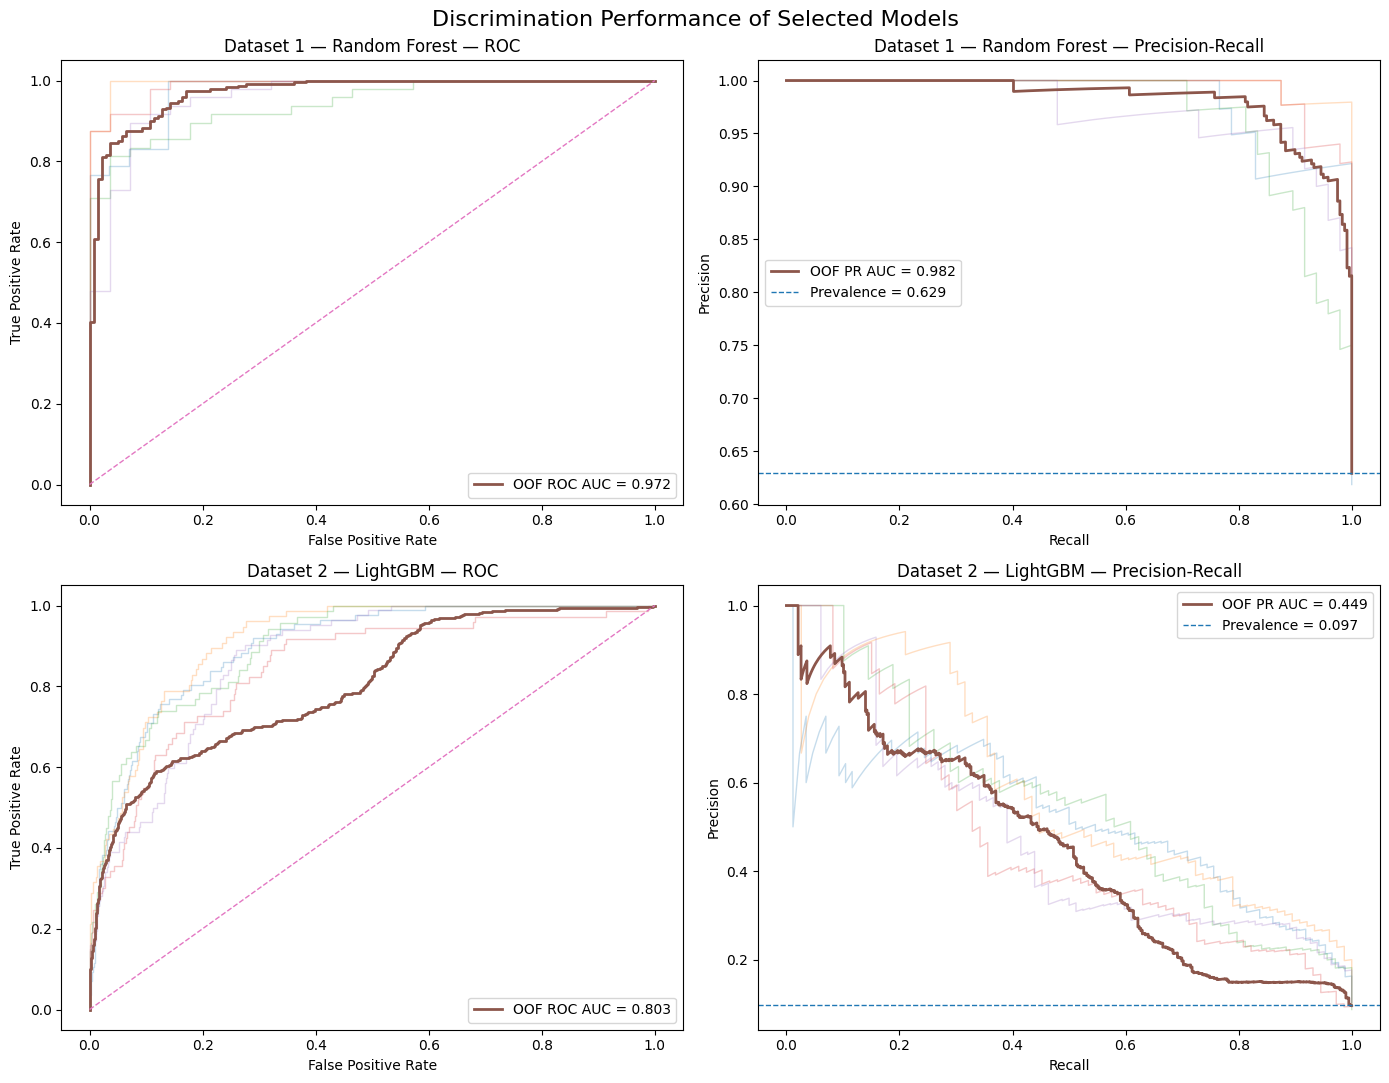

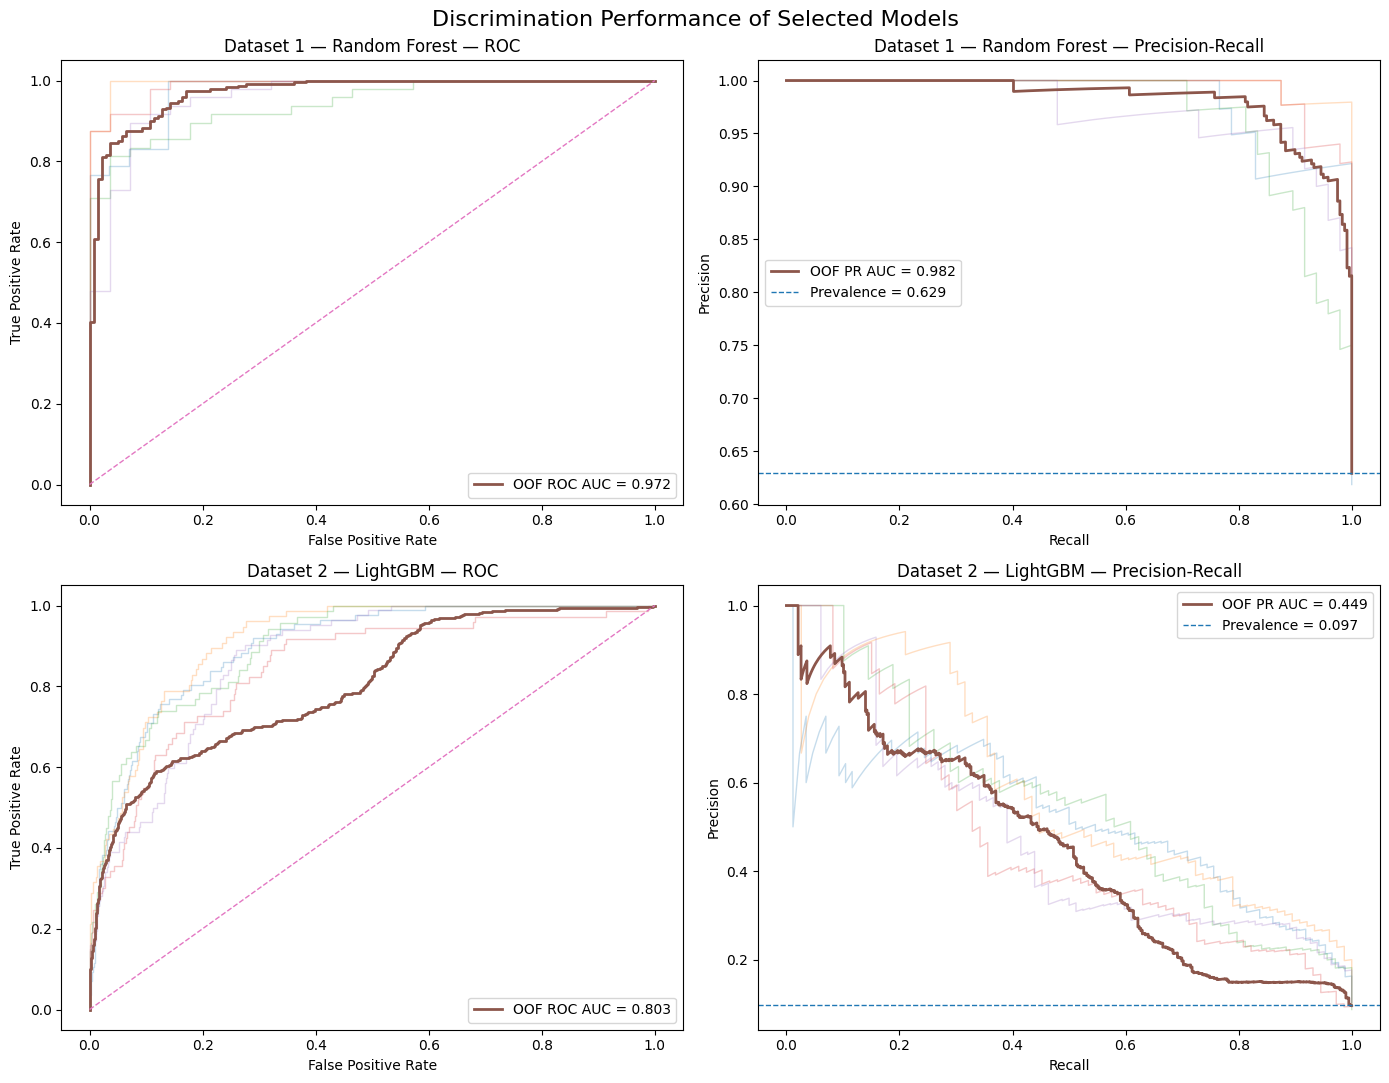

In [106]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 11)
)

plot_roc_pr(
    pred_ds1,
    axes[0, 0],
    axes[0, 1],
    "Dataset 1 — Random Forest"
)

plot_roc_pr(
    pred_ds2,
    axes[1, 0],
    axes[1, 1],
    "Dataset 2 — LightGBM"
)

plt.suptitle(
    "Discrimination Performance of Selected Models",
    fontsize=16
)

plt.tight_layout()

plt.savefig(
    f"{FINAL_DIR}/Figure_2_ROC_PR.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Plot confusion matrix and calibration curve

In [111]:
def plot_confusion_matrix(
    pred,
    ax,
    title
):

    cm = confusion_matrix(
        pred["y_true"],
        pred["y_pred"]
    )

    ax.imshow(cm)

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])

    ax.set_xticklabels([
        "No CKD",
        "CKD"
    ])

    ax.set_yticklabels([
        "No CKD",
        "CKD"
    ])

    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

    ax.set_title(title)

    for i in range(2):
        for j in range(2):

            ax.text(
                j,
                i,
                str(cm[i, j]),
                ha="center",
                va="center",
                fontsize=14
            )

    return cm

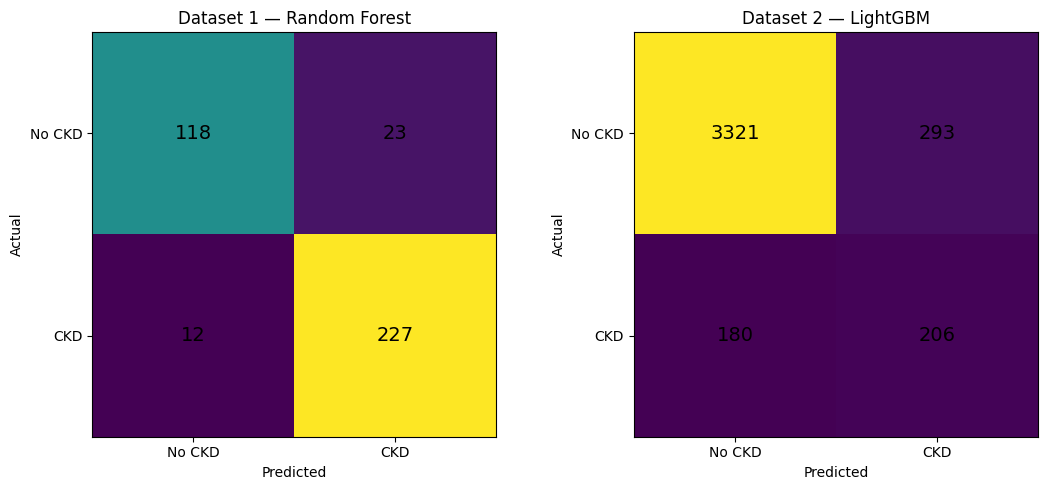

In [113]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(11, 5)
)

cm_ds1 = plot_confusion_matrix(
    pred_ds1,
    axes[0],
    "Dataset 1 — Random Forest"
)

cm_ds2 = plot_confusion_matrix(
    pred_ds2,
    axes[1],
    "Dataset 2 — LightGBM"
)

plt.tight_layout()

plt.savefig(
    f"{FINAL_DIR}/Confusion_Matrices.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [114]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

In [115]:
def plot_calibration(
    pred,
    ax,
    title,
    n_bins=10
):

    fraction_pos, mean_pred = calibration_curve(
        pred["y_true"],
        pred["y_prob"],
        n_bins=n_bins,
        strategy="quantile"
    )

    brier = brier_score_loss(
        pred["y_true"],
        pred["y_prob"]
    )

    ax.plot(
        mean_pred,
        fraction_pos,
        marker="o",
        linewidth=2,
        label=f"Brier = {brier:.3f}"
    )

    ax.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        linewidth=1,
        label="Perfect calibration"
    )

    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Observed proportion")
    ax.set_title(title)
    ax.legend()

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

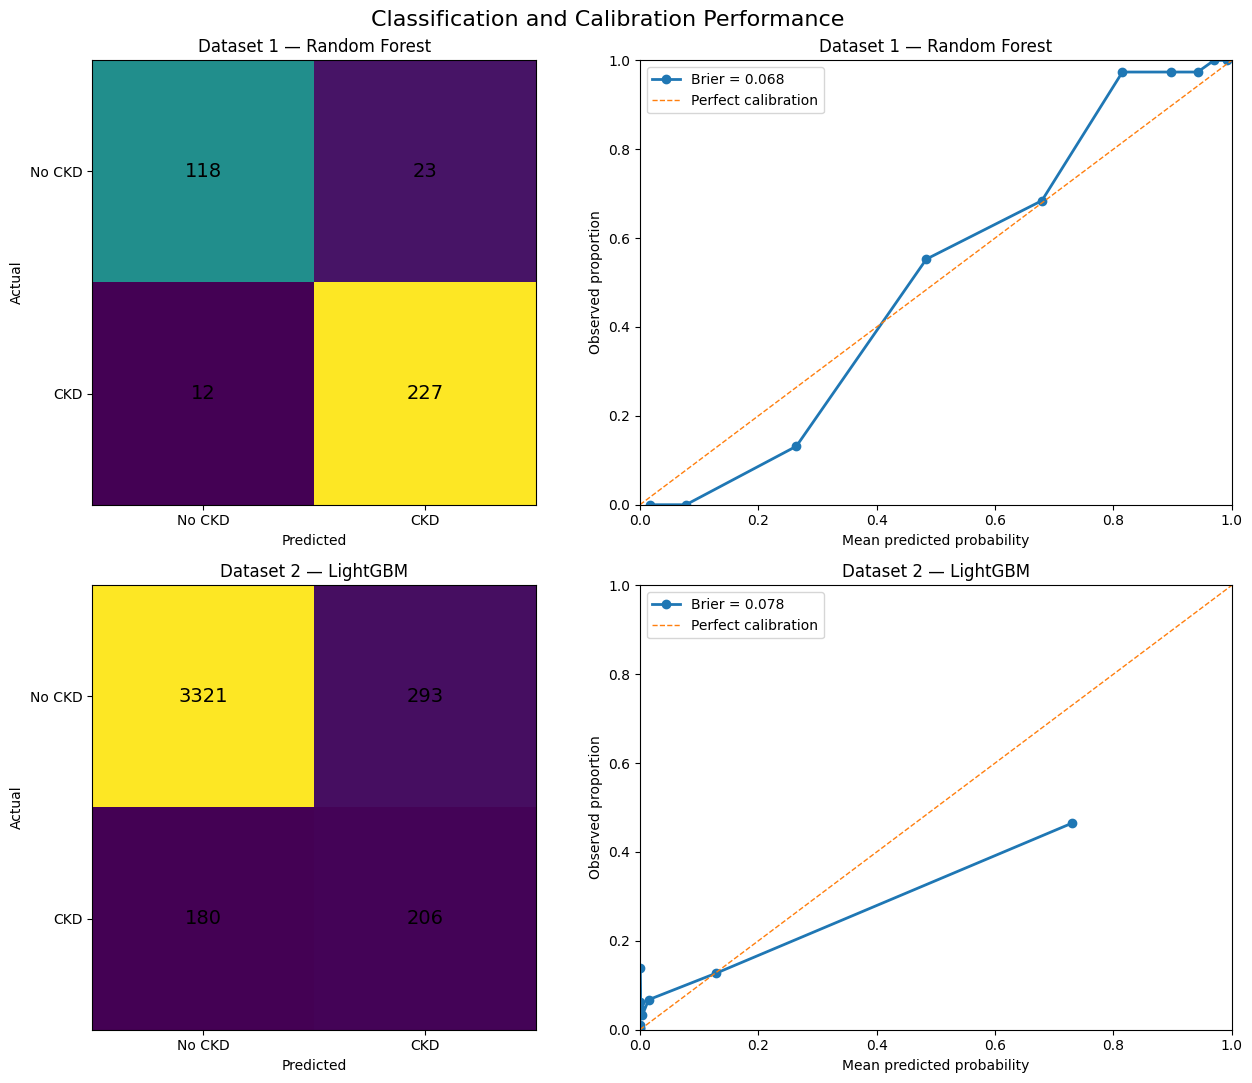

In [116]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(13, 11)
)

# -------------------------
# Dataset 1 confusion matrix
# -------------------------

plot_confusion_matrix(
    pred_ds1,
    axes[0, 0],
    "Dataset 1 — Random Forest"
)

# -------------------------
# Dataset 1 calibration
# -------------------------

plot_calibration(
    pred_ds1,
    axes[0, 1],
    "Dataset 1 — Random Forest"
)

# -------------------------
# Dataset 2 confusion matrix
# -------------------------

plot_confusion_matrix(
    pred_ds2,
    axes[1, 0],
    "Dataset 2 — LightGBM"
)

# -------------------------
# Dataset 2 calibration
# -------------------------

plot_calibration(
    pred_ds2,
    axes[1, 1],
    "Dataset 2 — LightGBM"
)

plt.suptitle(
    "Classification and Calibration Performance",
    fontsize=16
)

plt.tight_layout()

plt.savefig(
    f"{FINAL_DIR}/Figure_3_Confusion_Calibration.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()